In [ ]:
!pip -q uninstall -y transformers tokenizers accelerate

# Install stable versions
!pip -q install transformers==4.55.4
!pip -q install tokenizers==0.21.4
!pip -q install accelerate==1.10.1
!pip -q install datasets==4.0.0
!pip -q install evaluate==0.4.5
!pip -q install scikit-learn==1.7.1
!pip -q install seaborn

print("✅ Installation Completed")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.19.1 requires accelerate>=0.21.0, which is not installed.
✅ Installation Completed


In [ ]:
import transformers
import torch
import sklearn
import datasets
import evaluate

print("="*50)
print("Transformers :", transformers.__version__)
print("PyTorch      :", torch.__version__)
print("Sklearn      :", sklearn.__version__)
print("Datasets     :", datasets.__version__)
print("Evaluate     :", evaluate.__version__)
print("="*50)

Transformers : 4.55.4
PyTorch      : 2.11.0+cu128
Sklearn      : 1.7.1
Datasets     : 4.0.0
Evaluate     : 0.4.5


In [ ]:
import torch

print("="*50)

if torch.cuda.is_available():

    print("✅ GPU Available")

    print("GPU Name :", torch.cuda.get_device_name(0))

    print("CUDA Version :", torch.version.cuda)

else:

    print("❌ GPU Not Available")

print("="*50)

✅ GPU Available
GPU Name : Tesla T4
CUDA Version : 12.8


In [ ]:
# ==========================================================
# STEP 2 : Import Required Libraries
# ==========================================================

import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

import torch
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [ ]:
# ==========================================================
# STEP 2.2 : Random Seed
# ==========================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("✅ Random Seed Set")

✅ Random Seed Set


In [ ]:
# ==========================================================
# STEP 2.3 : GPU Detection
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

print("="*60)

Device : cuda
GPU : Tesla T4


In [ ]:
# ==========================================================
# STEP 2.4 : Upload Dataset
# ==========================================================

from google.colab import files

uploaded = files.upload()

Saving Fake.csv to Fake (1).csv
Saving True.csv to True (1).csv


In [ ]:
# ==========================================================
# STEP 2.5 : Read Dataset
# ==========================================================

fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

print("Fake Shape :", fake_df.shape)
print("True Shape :", true_df.shape)

Fake Shape : (10000, 4)
True Shape : (10000, 4)


In [ ]:
# ==========================================================
# STEP 2.6 : First Five Rows
# ==========================================================

display(fake_df.head())

display(true_df.head())

,title,text,subject,date
0,ABOUT HILLARY’S COUGH: We Discovered The Secre...,,politics,"Jul 20, 2016"
1,BREAKING: OBAMACARE REPEAL Clears First Hurdle...,The Senate voted 51-48 this afternoon to proce...,politics,"Jan 4, 2017"
2,‘SLEEPY’ JUSTICE GINSBURG: Excites Crowd By Sa...,So much for the SCOTUS not being political Che...,left-news,"Feb 7, 2017"
3,WATCH: Kellyanne Conway Very Upset Hillary Cl...,White House counselor Kellyanne Conway crawled...,News,"August 24, 2017"
4,"GOP Gives Trump The Middle Finger, Prepares T...",Donald Trump may have decided that Russia is g...,News,"December 9, 2016"


,title,text,subject,date
0,Europe rights watchdog says Turkey's emergency...,BRUSSELS (Reuters) - A leading European rights...,worldnews,"October 6, 2017"
1,Exclusive: Trump targets illegal immigrants wh...,"(Reuters) - In September 2014, Gilberto Velasq...",politicsNews,"June 9, 2017"
2,"At G20 summit, Trump pledges $639 million in a...",HAMBURG (Reuters) - U.S. President Donald Trum...,politicsNews,"July 8, 2017"
3,Ex-Christie associates lose bid for new trial ...,NEW YORK (Reuters) - A federal judge rejected ...,politicsNews,"March 2, 2017"
4,Young blacks more open to Bernie Sanders' Whit...,"ORANGEBURG, S.C. (Reuters) - If Democratic hop...",politicsNews,"February 12, 2016"


In [ ]:
# ==========================================================
# STEP 2.7 : Dataset Information
# ==========================================================

print(fake_df.info())

print()

print(true_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    10000 non-null  object
 1   text     10000 non-null  object
 2   subject  10000 non-null  object
 3   date     10000 non-null  object
dtypes: object(4)
memory usage: 312.6+ KB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    10000 non-null  object
 1   text     10000 non-null  object
 2   subject  10000 non-null  object
 3   date     10000 non-null  object
dtypes: object(4)
memory usage: 312.6+ KB
None


In [ ]:
# ==========================================================
# STEP 2.8 : Missing Values
# ==========================================================

print("Fake Dataset")

print(fake_df.isnull().sum())

print()

print("True Dataset")

print(true_df.isnull().sum())

Fake Dataset
title      0
text       0
subject    0
date       0
dtype: int64

True Dataset
title      0
text       0
subject    0
date       0
dtype: int64


In [ ]:
# ==========================================================
# STEP 2.9 : Duplicate Rows
# ==========================================================

print("Fake Duplicates :", fake_df.duplicated().sum())

print("True Duplicates :", true_df.duplicated().sum())

Fake Duplicates : 0
True Duplicates : 62


In [ ]:
# ==========================================================
# STEP 2.10 : Dataset Statistics
# ==========================================================

print("Fake Dataset Statistics")

display(fake_df.describe(include="all"))

print()

print("True Dataset Statistics")

display(true_df.describe(include="all"))

Fake Dataset Statistics


,title,text,subject,date
count,10000,10000,10000,10000
unique,8953,8717,6,1645
top,French Journalist Hit With Huge Fine For “Inci...,,News,"February 24, 2016"
freq,3,265,3895,21



True Dataset Statistics


,title,text,subject,date
count,10000,10000,10000,10000
unique,9848,9935,2,695
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"December 20, 2017"
freq,5,5,5300,79


In [ ]:
# ==========================================================
# STEP 8 : Create Labels
# ==========================================================

fake = fake_df.copy()
true = true_df.copy()

fake["label"] = 0
true["label"] = 1

print(fake.head())
print(true.head())

                                               title  \
0  ABOUT HILLARY’S COUGH: We Discovered The Secre...   
1  BREAKING: OBAMACARE REPEAL Clears First Hurdle...   
2  ‘SLEEPY’ JUSTICE GINSBURG: Excites Crowd By Sa...   
3   WATCH: Kellyanne Conway Very Upset Hillary Cl...   
4   GOP Gives Trump The Middle Finger, Prepares T...   

                                                text    subject  \
0                                                      politics   
1  The Senate voted 51-48 this afternoon to proce...   politics   
2  So much for the SCOTUS not being political Che...  left-news   
3  White House counselor Kellyanne Conway crawled...       News   
4  Donald Trump may have decided that Russia is g...       News   

               date  label  
0      Jul 20, 2016      0  
1       Jan 4, 2017      0  
2       Feb 7, 2017      0  
3   August 24, 2017      0  
4  December 9, 2016      0  
                                               title  \
0  Europe rights watchdog says

In [ ]:
# ==========================================================
# STEP 9 : Remove Missing Values
# ==========================================================

print("Before")

print(fake.shape)
print(true.shape)

fake.dropna(inplace=True)
true.dropna(inplace=True)

print("\nAfter")

print(fake.shape)
print(true.shape)

Before
(10000, 5)
(10000, 5)

After
(10000, 5)
(10000, 5)


In [ ]:
# ==========================================================
# STEP 10 : Remove Duplicate Rows
# ==========================================================

print("Duplicates Before")

print(fake.duplicated().sum())
print(true.duplicated().sum())

fake.drop_duplicates(inplace=True)
true.drop_duplicates(inplace=True)

print("\nDuplicates After")

print(fake.duplicated().sum())
print(true.duplicated().sum())

Duplicates Before
0
62

Duplicates After
0
0


In [ ]:
# ==========================================================
# STEP 11 : Remove Empty Articles
# ==========================================================

fake = fake[
    (fake["title"].str.strip()!="") &
    (fake["text"].str.strip()!="")
]

true = true[
    (true["title"].str.strip()!="") &
    (true["text"].str.strip()!="")
]

print(fake.shape)
print(true.shape)

(9732, 5)
(9937, 5)


In [ ]:
# ==========================================================
# STEP 12 : Remove URLs
# ==========================================================

import re

def remove_urls(text):

    text = re.sub(r"http\S+"," ",text)
    text = re.sub(r"www\S+"," ",text)

    return text

fake["text"] = fake["text"].apply(remove_urls)
true["text"] = true["text"].apply(remove_urls)

In [ ]:
# ==========================================================
# STEP 13 : Remove HTML
# ==========================================================

def remove_html(text):

    return re.sub(r"<.*?>"," ",text)

fake["text"] = fake["text"].apply(remove_html)
true["text"] = true["text"].apply(remove_html)

In [ ]:
# ==========================================================
# STEP 14 : Remove Special Characters
# ==========================================================

def clean_text(text):

    text = re.sub(r"[^a-zA-Z0-9\s]"," ",text)

    return text

fake["title"] = fake["title"].apply(clean_text)
fake["text"] = fake["text"].apply(clean_text)

true["title"] = true["title"].apply(clean_text)
true["text"] = true["text"].apply(clean_text)

In [ ]:
# ==========================================================
# STEP 15 : Remove Extra Spaces
# ==========================================================

def clean_spaces(text):

    text = re.sub(r"\s+"," ",text)

    return text.strip()

fake["title"] = fake["title"].apply(clean_spaces)
fake["text"] = fake["text"].apply(clean_spaces)

true["title"] = true["title"].apply(clean_spaces)
true["text"] = true["text"].apply(clean_spaces)

In [ ]:
# ==========================================================
# STEP 16 : Merge Title + Text
# ==========================================================

fake["content"] = fake["title"] + " " + fake["text"]

true["content"] = true["title"] + " " + true["text"]

In [ ]:
# ==========================================================
# STEP 17 : Keep Only Required Columns
# ==========================================================

fake = fake[["content","label"]]
true = true[["content","label"]]

In [ ]:
# ==========================================================
# STEP 18 : Merge Dataset
# ==========================================================

df = pd.concat(
    [fake,true],
    ignore_index=True
)

print(df.shape)

(19669, 2)


In [ ]:
# ==========================================================
# STEP 19 : Remove Duplicate Articles
# ==========================================================

print("Before :",len(df))

df.drop_duplicates(
    subset=["content"],
    inplace=True
)

df.reset_index(
    drop=True,
    inplace=True
)

print("After :",len(df))

Before : 19669
After : 18592


In [ ]:
# ==========================================================
# STEP 20 : Shuffle Dataset
# ==========================================================

df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df.head()

,content,label
0,Elizabeth Warren BURIES Trump After He Throws ...,0
1,WHITE STUDENTS TURNED AWAY FROM Anti Racism Ev...,0
2,Fox News Yuks It Up Taunts The Donald Over The...,0
3,Sanders Clinton cool to Bloomberg s possible e...,1
4,U S Senate leader expects review of healthcare...,1


In [ ]:
# ==========================================================
# STEP 21 : Dataset Information
# ==========================================================

print(df.info())

print()

display(df.head())

print()

print(df["label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18592 entries, 0 to 18591
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  18592 non-null  object
 1   label    18592 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 290.6+ KB
None



,content,label
0,Elizabeth Warren BURIES Trump After He Throws ...,0
1,WHITE STUDENTS TURNED AWAY FROM Anti Racism Ev...,0
2,Fox News Yuks It Up Taunts The Donald Over The...,0
3,Sanders Clinton cool to Bloomberg s possible e...,1
4,U S Senate leader expects review of healthcare...,1



label
1    9874
0    8718
Name: count, dtype: int64


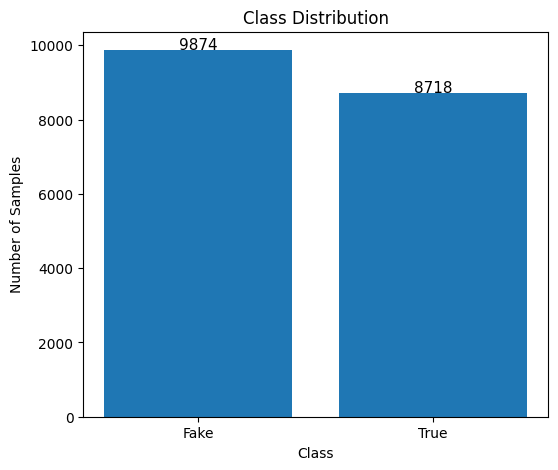

In [ ]:
# ==========================================================
# STEP 22 : Class Distribution
# ==========================================================

import matplotlib.pyplot as plt

counts = df["label"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    ["Fake","True"],
    counts.values
)

plt.title("Class Distribution")

plt.xlabel("Class")

plt.ylabel("Number of Samples")

for i,v in enumerate(counts.values):

    plt.text(
        i,
        v+20,
        str(v),
        ha="center",
        fontsize=11
    )

plt.show()

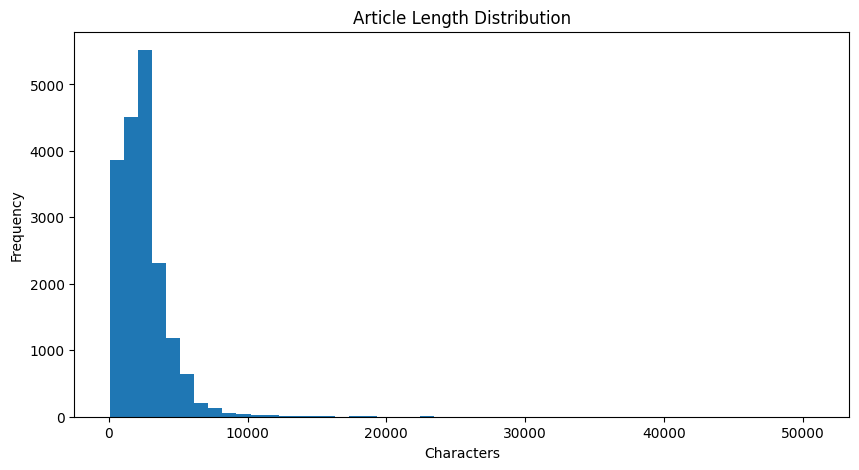

In [ ]:
# ==========================================================
# STEP 23 : Article Length
# ==========================================================

df["length"] = df["content"].apply(len)

plt.figure(figsize=(10,5))

plt.hist(
    df["length"],
    bins=50
)

plt.title("Article Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [ ]:
# ==========================================================
# STEP 24 : Remove Temporary Column
# ==========================================================

if "length" in df.columns:
    df.drop(columns=["length"], inplace=True)

print(df.head())

                                             content  label
0  Elizabeth Warren BURIES Trump After He Throws ...      0
1  WHITE STUDENTS TURNED AWAY FROM Anti Racism Ev...      0
2  Fox News Yuks It Up Taunts The Donald Over The...      0
3  Sanders Clinton cool to Bloomberg s possible e...      1
4  U S Senate leader expects review of healthcare...      1


In [ ]:
# ==========================================================
# STEP 25 : Features and Labels
# ==========================================================

X = df["content"]
y = df["label"]

print("Total Samples :", len(X))

Total Samples : 18592


In [ ]:
# ==========================================================
# STEP 26 : Train / Validation / Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

# 70% Train
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% Validation
# 15% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("="*50)
print("Training :", len(X_train))
print("Validation :", len(X_val))
print("Testing :", len(X_test))
print("="*50)

Training : 13014
Validation : 2789
Testing : 2789


In [ ]:
# ==========================================================
# STEP 27 : Verify Class Balance
# ==========================================================

print("Training")

print(y_train.value_counts())

print()

print("Validation")

print(y_val.value_counts())

print()

print("Testing")

print(y_test.value_counts())

Training
label
1    6912
0    6102
Name: count, dtype: int64

Validation
label
1    1481
0    1308
Name: count, dtype: int64

Testing
label
1    1481
0    1308
Name: count, dtype: int64


In [ ]:
# ==========================================================
# STEP 28 : Load Tokenizer
# ==========================================================

from transformers import BertTokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer Loaded Successfully")

Tokenizer Loaded Successfully


In [ ]:
# ==========================================================
# STEP 29 : Tokenize Training Data
# ==========================================================

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

In [ ]:
# ==========================================================
# STEP 31 : Tokenize Test Data
# ==========================================================

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

print("Tokenization Completed")

Tokenization Completed


In [ ]:
# ==========================================================
# STEP 32 : Verify Tokenization
# ==========================================================

print("Input Length :", len(train_encodings["input_ids"][0]))
print("Attention Mask Length :", len(train_encodings["attention_mask"][0]))

print()

print(tokenizer.decode(train_encodings["input_ids"][0][:80]))

Input Length : 256
Attention Mask Length : 256

[CLS] chess federation says israel excluded from saudi hosted match athens reuters israeli players have been denied visas to participate in a speed chess championship hosted by saudi arabia this week a vice president of the world chess federation fide said on sunday seven israeli players had requested visas for the tournament on dec 26 30 it would have marked the first time saudi arabia had publicly hosted israelis as the gulf state does not recognize israel and there are


In [ ]:
# ==========================================================
# STEP 33 : PyTorch Dataset
# ==========================================================

from torch.utils.data import Dataset
import torch

class FakeNewsDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx], dtype=torch.long)
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return item

In [ ]:
print("train_encodings" in globals())
print("val_encodings" in globals())
print("test_encodings" in globals())

True
False
True


In [ ]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

In [ ]:
val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

In [ ]:
test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=256
)

In [ ]:
# ==========================================================
# STEP 34 : Dataset Objects
# ==========================================================

train_dataset = FakeNewsDataset(
    train_encodings,
    y_train
)

val_dataset = FakeNewsDataset(
    val_encodings,
    y_val
)

test_dataset = FakeNewsDataset(
    test_encodings,
    y_test
)

print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

Train : 13014
Validation : 2789
Test : 2789


In [ ]:
# ==========================================================
# STEP 35 : Data Collator
# ==========================================================

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Data Collator Ready")

Data Collator Ready


In [ ]:
# ==========================================================
# STEP 36 : DataLoader
# ==========================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

print("Train Batches :", len(train_loader))
print("Validation Batches :", len(val_loader))
print("Test Batches :", len(test_loader))

Train Batches : 814
Validation Batches : 175
Test Batches : 175


In [ ]:
# ==========================================================
# STEP 37 : Verify Dataset
# ==========================================================

sample = train_dataset[0]

print(sample.keys())

print()

print("Input IDs Shape :", sample["input_ids"].shape)

print("Attention Mask Shape :", sample["attention_mask"].shape)

print("Label :", sample["labels"])

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])

Input IDs Shape : torch.Size([256])
Attention Mask Shape : torch.Size([256])
Label : tensor(1)


In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3
)

model.to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.3, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.3, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
# ==========================================================
# STEP 39 : Optimizer
# ==========================================================

from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=1e-5,
    weight_decay=0.05
)

print("Optimizer Ready")

Optimizer Ready


In [ ]:
# ==========================================================
# STEP 40 : Scheduler
# ==========================================================

from transformers import get_linear_schedule_with_warmup

epochs = 5

total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print("Scheduler Ready")

Scheduler Ready


In [ ]:
# ==========================================================
# STEP 41 : Loss Function
# ==========================================================

criterion = torch.nn.CrossEntropyLoss()

print("Loss Function Ready")

Loss Function Ready


In [ ]:
# ==========================================================
# STEP 42 : Store Training History
# ==========================================================

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_loss = float("inf")

patience = 2

counter = 0

In [ ]:
# ==========================================================
# STEP 43 : Training Loop
# ==========================================================

from tqdm.auto import tqdm

for epoch in range(epochs):

    print("="*60)
    print(f"Epoch {epoch+1}/{epochs}")
    print("="*60)

    ############################
    # TRAIN
    ############################

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    loop = tqdm(train_loader)

    for batch in loop:

        batch = {k:v.to(device) for k,v in batch.items()}

        optimizer.zero_grad()

        outputs = model(**batch)

        loss = outputs.loss

        logits = outputs.logits

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        scheduler.step()

        running_loss += loss.item()

        preds = torch.argmax(logits,dim=1)

        correct += (preds==batch["labels"]).sum().item()

        total += batch["labels"].size(0)

        loop.set_postfix(loss=loss.item())

    train_loss = running_loss/len(train_loader)

    train_acc = correct/total

    ############################
    # VALIDATION
    ############################

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for batch in val_loader:

            batch = {k:v.to(device) for k,v in batch.items()}

            outputs = model(**batch)

            loss = outputs.loss

            logits = outputs.logits

            running_loss += loss.item()

            preds = torch.argmax(logits,dim=1)

            correct += (preds==batch["labels"]).sum().item()

            total += batch["labels"].size(0)

    val_loss = running_loss/len(val_loader)

    val_acc = correct/total

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    train_accs.append(train_acc)

    val_accs.append(val_acc)

    print()

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Validation Loss : {val_loss:.4f}")

    print(f"Train Accuracy : {train_acc:.4f}")

    print(f"Validation Accuracy : {val_acc:.4f}")

    ############################
    # SAVE BEST MODEL
    ############################

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            "best_bert_model.pth"
        )

        counter = 0

        print("✅ Best Model Saved")

    else:

        counter += 1

        print("EarlyStopping Counter :",counter)

        if counter>=patience:

            print("Early Stopping")

            break

Epoch 1/5


  0%|          | 0/814 [00:00<?, ?it/s]


Train Loss : 0.1056
Validation Loss : 0.0505
Train Accuracy : 0.9614
Validation Accuracy : 0.9910
✅ Best Model Saved
Epoch 2/5


  0%|          | 0/814 [00:00<?, ?it/s]


Train Loss : 0.0191
Validation Loss : 0.0354
Train Accuracy : 0.9963
Validation Accuracy : 0.9935
✅ Best Model Saved
Epoch 3/5


...


Train Loss : 0.0130
Validation Loss : 0.0241
Train Accuracy : 0.9978
Validation Accuracy : 0.9950
✅ Best Model Saved
Epoch 4/5


  0%|          | 0/814 [00:00<?, ?it/s]


Train Loss : 0.0082
Validation Loss : 0.0362
Train Accuracy : 0.9985
Validation Accuracy : 0.9921
EarlyStopping Counter : 1
Epoch 5/5


  0%|          | 0/814 [00:00<?, ?it/s]


Train Loss : 0.0035
Validation Loss : 0.0570
Train Accuracy : 0.9992
Validation Accuracy : 0.9867
EarlyStopping Counter : 2
Early Stopping


In [ ]:
# ==========================================================
# STEP 44 : Load Best Model
# ==========================================================

model.load_state_dict(
    torch.load("best_bert_model.pth")
)

model.eval()

print("Best Model Loaded")

Best Model Loaded


In [ ]:
# ==========================================================
# STEP 45 : Test Model
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for batch in test_loader:

        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)

        logits = outputs.logits

        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(logits, dim=1)

        y_true.extend(batch["labels"].cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs[:,1].cpu().numpy())

In [ ]:
# ==========================================================
# STEP 46 : Evaluation Metrics
# ==========================================================

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("="*50)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

print("="*50)

Accuracy : 0.9946217282179993
Precision : 0.9899732620320856
Recall : 1.0
F1 Score : 0.994961370507222


In [ ]:
# ==========================================================
# STEP 47 : Classification Report
# ==========================================================

print(classification_report(
    y_true,
    y_pred,
    target_names=["Fake","True"]
))

              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      1308
        True       0.99      1.00      0.99      1481

    accuracy                           0.99      2789
   macro avg       0.99      0.99      0.99      2789
weighted avg       0.99      0.99      0.99      2789



In [ ]:
# ==========================================================
# STEP 48 : Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[1293   15]
 [   0 1481]]


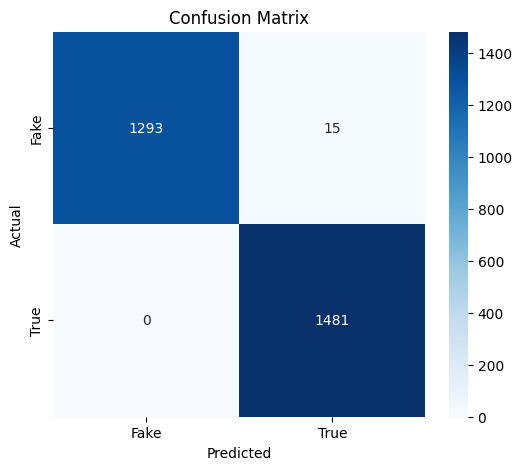

In [ ]:
# ==========================================================
# STEP 49 : Confusion Matrix Plot
# ==========================================================

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake","True"],
    yticklabels=["Fake","True"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

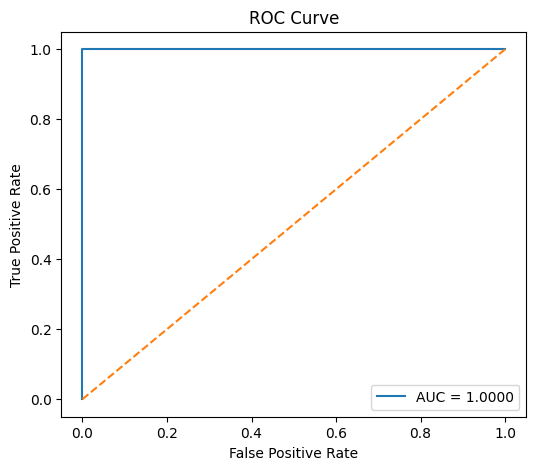

In [ ]:
# ==========================================================
# STEP 50 : ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(
    y_true,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

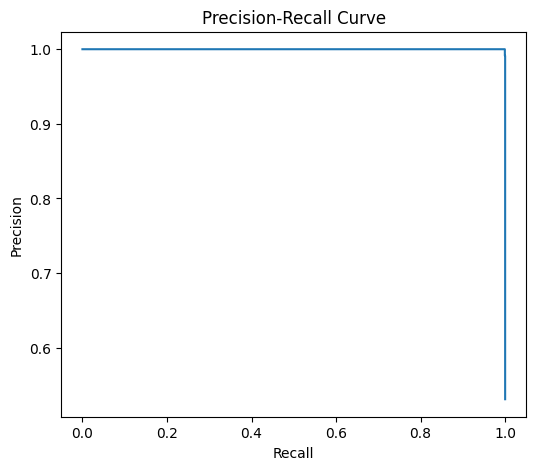

In [ ]:
# ==========================================================
# STEP 51 : Precision Recall Curve
# ==========================================================

from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(
    y_true,
    y_prob
)

plt.figure(figsize=(6,5))

plt.plot(
    recall_vals,
    precision_vals
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

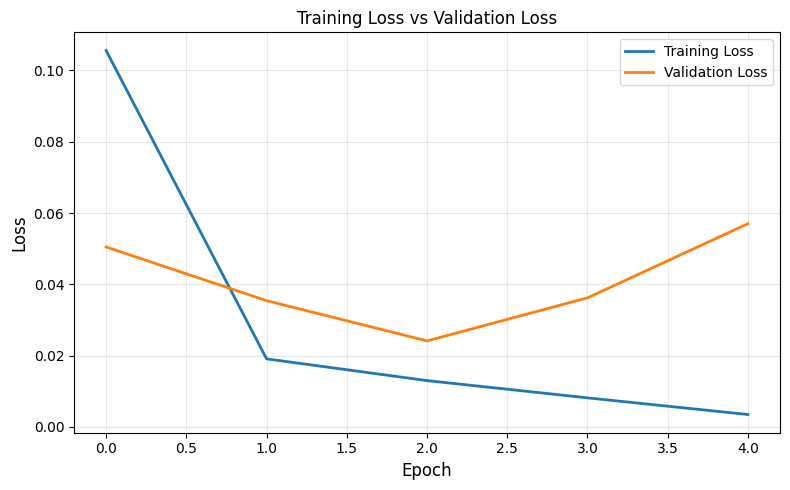

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,
         linewidth=2,
         label="Training Loss")

plt.plot(val_losses,
         linewidth=2,
         label="Validation Loss")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.title("Training Loss vs Validation Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

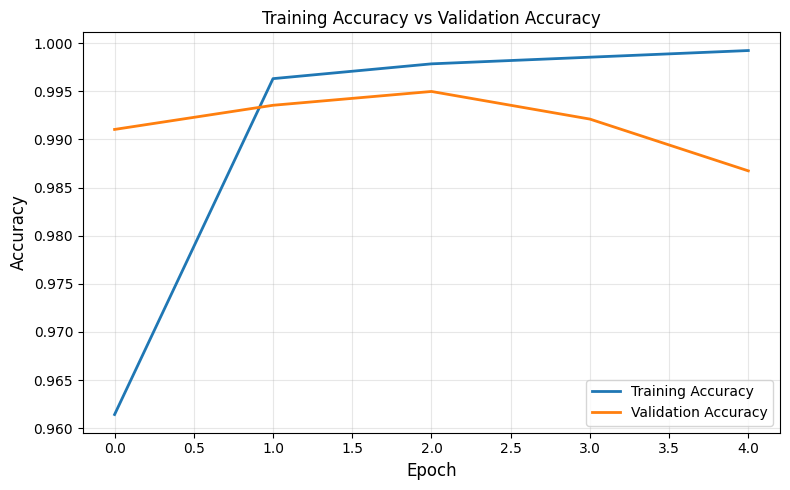

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_accs,
         linewidth=2,
         label="Training Accuracy")

plt.plot(val_accs,
         linewidth=2,
         label="Validation Accuracy")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)

plt.title("Training Accuracy vs Validation Accuracy")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

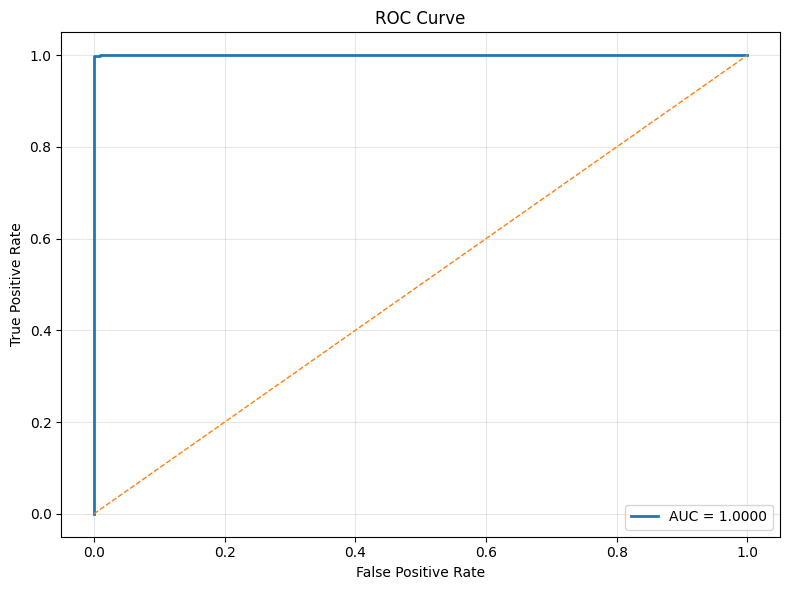

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(fpr,
         tpr,
         linewidth=2,
         label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],
         linestyle="--",
         linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

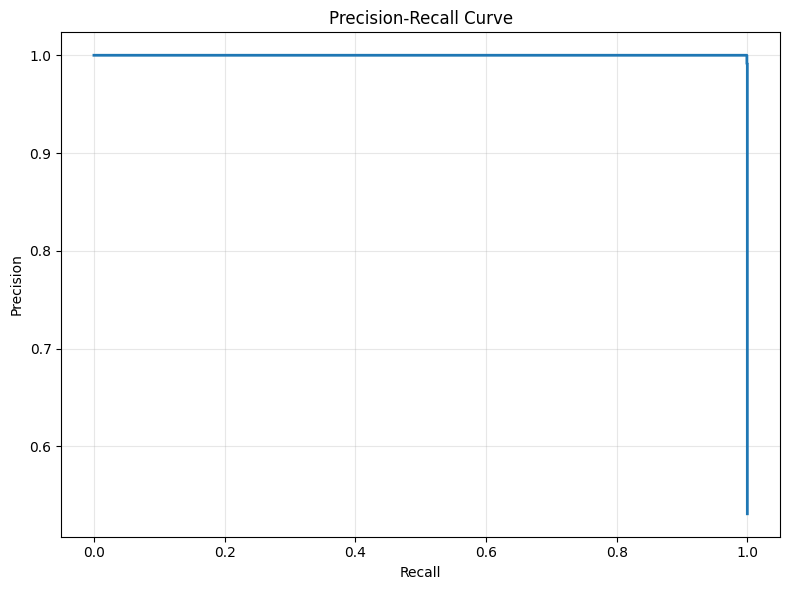

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(recall_vals,
         precision_vals,
         linewidth=2)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


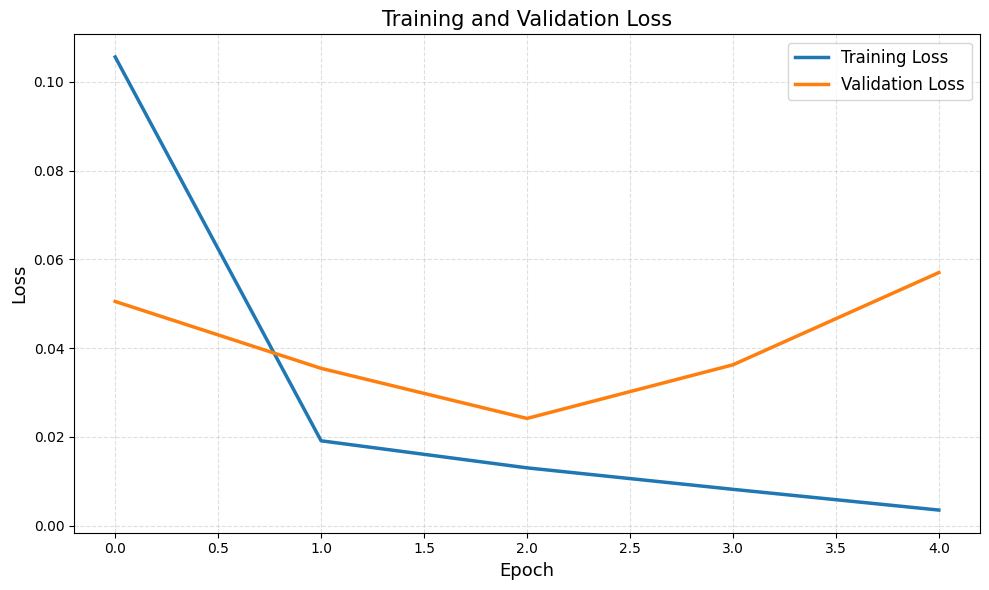

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    train_losses,
    label="Training Loss",
    linewidth=2.5
)

plt.plot(
    val_losses,
    label="Validation Loss",
    linewidth=2.5
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Loss", fontsize=13)

plt.title("Training and Validation Loss", fontsize=15)

plt.legend(fontsize=12)

plt.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig("Loss_Graph.png", dpi=300)

plt.show()